# Chunking and embedding-model analysis

Use this notebook before building the vector store. It measures **actual tokenizer lengths** on the cleaned WHO corpus, finds chunks that would be truncated, and compares retrieval quality for candidate embedding models.

Run cells in order. The first time a model is loaded, Hugging Face may download it.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'app').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Repository root: {ROOT}')

Repository root: /Users/suzannezhen/DEV/clinical-rag-assistant


## 1. Load and clean the local WHO PDFs

This uses only the PDFs already under `data/who`; it does not download content. Start with PDFs because they contain the long Drug Information entries that need the most chunking inspection.

In [ ]:
from app.data_loading.pdf_loader import load_pdfs_from_folder
from app.data_processing.cleaning import clean_documents

pdf_docs = load_pdfs_from_folder(
    folder=str(ROOT / 'data/who'),
    source_name='WHO IRIS Publications',
    manifest_path=str(ROOT / 'data/who/manifest_iris.json'),
)
cleaned_docs = clean_documents(pdf_docs)

print(f'Loaded pages: {len(pdf_docs):,}')
print(f'Cleaned pages: {len(cleaned_docs):,}')

Loaded 7 manifest entries from /Users/suzannezhen/DEV/clinical-rag-assistant/data/who/manifest_iris.json
Loading: WER-101-30-eng.pdf
  Loaded 23 pages
Loading: WER-101-31-eng.pdf
  Loaded 9 pages
Loading: WHO_drug_information_2026_v40_1.pdf
  Loaded 278 pages
Loading: WHO_drug_information_2026_v40_2.pdf
  Loaded 493 pages
Loaded 803 page documents from 4 PDFs.
Loaded pages: 803
Cleaned pages: 803


## 2. Choose models and chunk configurations

`all-MiniLM-L6-v2` is a fast general-purpose baseline. `NeuML/pubmedbert-base-embeddings` is a biomedical retrieval model. The analysis below uses each model's real tokenizer rather than the chunker's character-based estimate.

In [ ]:
from app.data_processing.chunking import ChunkerConfig, chunk_documents
from app.embeddings import load_embedding_model

MODEL_NAMES = {
    'MiniLM baseline': 'sentence-transformers/all-MiniLM-L6-v2',
    'PubMedBERT embeddings': 'NeuML/pubmedbert-base-embeddings',
}

CHUNK_CONFIGS = [
    ChunkerConfig(target_tokens=120, overlap_tokens=25),
    ChunkerConfig(target_tokens=160, overlap_tokens=30),
    ChunkerConfig(target_tokens=200, overlap_tokens=40),
]

# Set this to an integer while experimenting to run on only the first N cleaned pages.
MAX_PAGES = None
analysis_docs = cleaned_docs[:MAX_PAGES] if MAX_PAGES else cleaned_docs

## 3. Compare chunk sizes using real model tokens

A good configuration has zero chunks larger than the model limit, a moderate number of chunks, and a healthy median size. Target approximately 80–90% of the model's context limit at most.

In [ ]:
def token_count(text, tokenizer):
    encoded = tokenizer(text, add_special_tokens=True, truncation=False)
    return len(encoded['input_ids'])

length_rows = []
chunks_by_config = {}
lengths_by_run = {}

for model_label, model_name in MODEL_NAMES.items():
    model = load_embedding_model(model_name)
    limit = model.max_seq_length

    for config in CHUNK_CONFIGS:
        config_key = (config.target_tokens, config.overlap_tokens)
        chunks = chunk_documents(analysis_docs, config)
        chunks_by_config[config_key] = chunks
        lengths = [token_count(chunk.page_content, model.tokenizer) for chunk in chunks]
        lengths_by_run[(model_label, config_key)] = lengths

        length_rows.append({
            'model': model_label,
            'model_limit': limit,
            'target_tokens': config.target_tokens,
            'overlap_tokens': config.overlap_tokens,
            'chunks': len(chunks),
            'median_actual_tokens': int(np.median(lengths)),
            'p95_actual_tokens': int(np.percentile(lengths, 95)),
            'max_actual_tokens': max(lengths),
            'over_limit_chunks': sum(length > limit for length in lengths),
            'over_limit_percent': round(100 * sum(length > limit for length in lengths) / len(lengths), 1),
        })

length_report = pd.DataFrame(length_rows)
display(length_report.sort_values(['model', 'target_tokens']))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (297 > 256). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (564 > 512). Running this sequence through the model will result in indexing errors


,model,model_limit,target_tokens,overlap_tokens,chunks,median_actual_tokens,p95_actual_tokens,max_actual_tokens,over_limit_chunks,over_limit_percent
0,MiniLM baseline,256,120,25,4175,99,615,1844,753,18.0
1,MiniLM baseline,256,160,30,3468,135,708,1844,873,25.2
2,MiniLM baseline,256,200,40,3025,169,759,1844,990,32.7
3,PubMedBERT embeddings,512,120,25,4175,93,546,1744,230,5.5
4,PubMedBERT embeddings,512,160,30,3468,124,619,1744,231,6.7
5,PubMedBERT embeddings,512,200,40,3025,154,676,1744,231,7.6


### Token-count distribution

Each line is a chunk configuration. The vertical dashed line is the selected embedding model's maximum input length. A long right tail beyond that line indicates text that needs fallback splitting rather than a different target size alone.

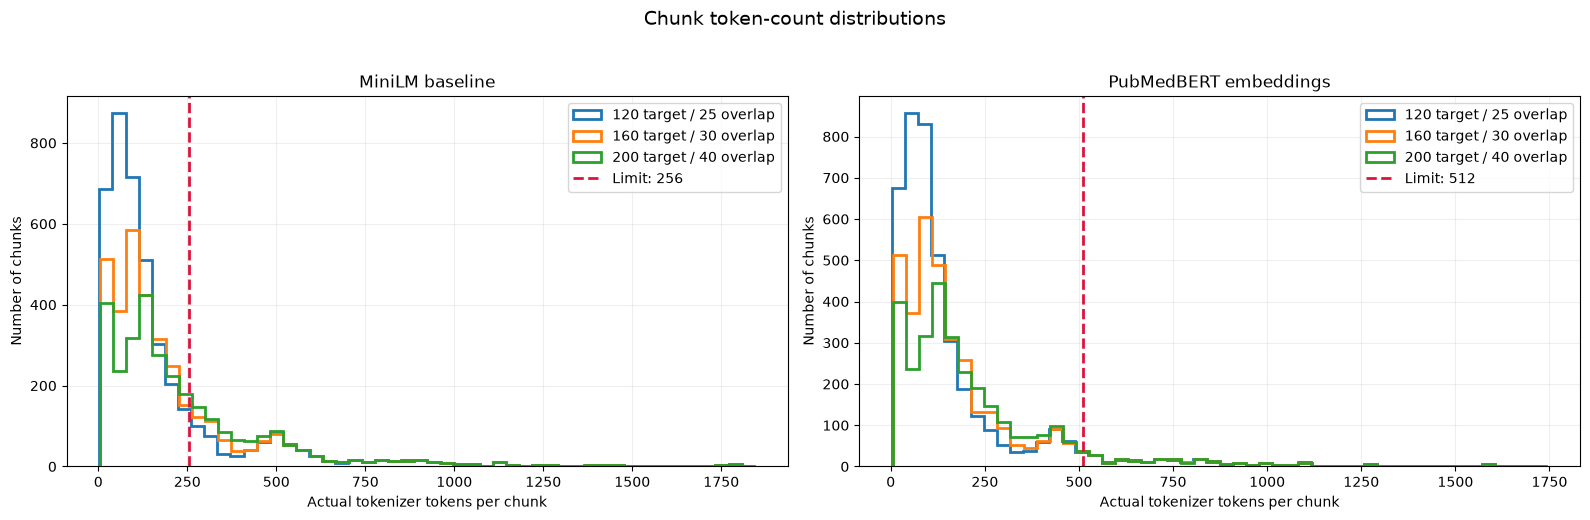

In [ ]:
model_labels = list(MODEL_NAMES)
fig, axes = plt.subplots(1, len(model_labels), figsize=(8 * len(model_labels), 5), squeeze=False)

for axis, model_label in zip(axes[0], model_labels):
    model_limit = int(length_report.loc[length_report['model'] == model_label, 'model_limit'].iloc[0])

    for config in CHUNK_CONFIGS:
        config_key = (config.target_tokens, config.overlap_tokens)
        lengths = lengths_by_run[(model_label, config_key)]
        axis.hist(
            lengths,
            bins=50,
            histtype='step',
            linewidth=2,
            label=f'{config.target_tokens} target / {config.overlap_tokens} overlap',
        )

    axis.axvline(model_limit, color='crimson', linestyle='--', linewidth=2, label=f'Limit: {model_limit}')
    axis.set_title(model_label)
    axis.set_xlabel('Actual tokenizer tokens per chunk')
    axis.set_ylabel('Number of chunks')
    axis.legend()
    axis.grid(alpha=0.2)

fig.suptitle('Chunk token-count distributions', y=1.03, fontsize=14)
fig.tight_layout()
plt.show()

## 4. Inspect oversized chunks

Large chunks are often Drug Information molecular entries, tables, or list-heavy PDF extraction. Inspect them before deciding whether to add a fallback line/word splitter or a source-specific policy.

In [15]:
# Change these two values to inspect a different model/configuration.
INSPECTION_MODEL = 'PubMedBERT embeddings'
INSPECTION_CONFIG = (200, 40)

inspection_model = load_embedding_model(MODEL_NAMES[INSPECTION_MODEL])
inspection_chunks = chunks_by_config[INSPECTION_CONFIG]

oversized = []
for chunk in inspection_chunks:
    length = token_count(chunk.page_content, inspection_model.tokenizer)
    if length > inspection_model.max_seq_length:
        oversized.append((chunk, length))

oversized_report = pd.DataFrame([
    {
        'tokens': length,
        'title': chunk.metadata.get('title'),
        'page': chunk.metadata.get('page_number'),
        'section': chunk.metadata.get('section_title'),
        'is_table': '[TABLE]' in chunk.page_content,
        'preview': chunk.page_content[:250].replace('\n', ' '),
    }
    for chunk, length in oversized
])
display(oversized_report.sort_values('tokens', ascending=False))

# Show one complete example. Change 0 to inspect another oversized chunk.
if oversized:
    example_chunk, example_length = oversized[0]
    print(f'Tokens: {example_length}')
    print(example_chunk.metadata)
    print(example_chunk.page_content)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (564 > 512). Running this sequence through the model will result in indexing errors


,tokens,title,page,section,is_table,preview
137,1744,"WHO Drug Information 2026, vol. 40, 2 [full is...",236,NaN,False,elzegurán ARN guía (gRNA) dirigido a un sitio ...
115,1643,"WHO Drug Information 2026, vol. 40, 2 [full is...",197,NaN,False,birfutamig inmunoglobulina (H-gamma1_L-kappa)_...
136,1611,"WHO Drug Information 2026, vol. 40, 2 [full is...",235,NaN,False,elzéguran ARN guide (gRNA) ciblant un site don...
111,1610,"WHO Drug Information 2026, vol. 40, 2 [full is...",192,NaN,False,besnotamig inmunoglobulina (H-gamma4_L-kappa)_...
41,1596,"WHO Drug Information 2026, vol. 40, 1 [full is...",128,NaN,False,"Recommended INN: List 95 WHO Drug Information,..."
...,...,...,...,...,...,...
145,519,"WHO Drug Information 2026, vol. 40, 2 [full is...",268,NaN,False,graxutamig immunoglobuline V-KAPPA-5mer-scFvhk...
123,518,"WHO Drug Information 2026, vol. 40, 2 [full is...",212,NaN,False,"dalvaprubart immunoglobuline G1-kappa, anti-[H..."
211,517,"WHO Drug Information 2026, vol. 40, 2 [full is...",420,NaN,False,vadenersén todo-P-ambo-2′-O-(2-metoxietil)-P-t...
36,515,"WHO Drug Information 2026, vol. 40, 1 [full is...",115,NaN,False,"lecomkafusp alfa interleukina-2 humana (IL-2, ..."


Tokens: 564
{'document_id': 'eef14589e173df76', 'source': 'https://iris.who.int/handle/10665/385136', 'source_type': 'pdf', 'source_name': 'WHO IRIS Publications', 'title': 'WHO Drug Information 2026, vol. 40, 1 [full issue]', 'description': 'Ensuring consistent identification and quality assurance of pharmaceutical substances is a fundamental component of global medicines regulation and patient safety. This issue of WHO Drug Information, a quarterly publication of the World Health Organization, presents a collection of technical and regulatory materials, including consultation documents and the latest Recommended International Nonproprietary Names (INN) for pharmaceutical substances.\n\nIt outlines draft monographs for dapsone and dapsone tablets intended for inclusion in The International Pharmacopoeia, detailing specifications for identity, purity, assay methods, and impurity control using standardized analytical techniques such as chromatography and spectrophotometry. The publicati